In [1]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Done! Files:")
for f in os.listdir('.'):
    print(f)

✅ Done! Files:
.config
archive (4).zip
googleplaystore.csv
license.txt
googleplaystore_user_reviews.csv
sample_data


In [2]:
import pandas as pd
import numpy as np

# Load both datasets
df = pd.read_csv('googleplaystore.csv')
reviews_df = pd.read_csv('googleplaystore_user_reviews.csv')

# Clean reviews dataset → keep only subjectivity
reviews_df = reviews_df[['App', 'Sentiment_Subjectivity']].dropna()
reviews_df['Sentiment_Subjectivity'] = pd.to_numeric(
    reviews_df['Sentiment_Subjectivity'], errors='coerce')

# Get average subjectivity per app
avg_subjectivity = reviews_df.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()

# Merge with main dataset
df = df.merge(avg_subjectivity, on='App', how='inner')

# Clean Installs → numeric
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Rating → numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Reviews → numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Clean Size → MB
def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return None

df['Size_MB'] = df['Size'].apply(convert_size)

# Drop nulls
df.dropna(subset=['Installs', 'Rating', 'Reviews', 'Size_MB', 'Sentiment_Subjectivity'], inplace=True)

print("✅ Data loaded and merged! Shape:", df.shape)
df.head()

✅ Data loaded and merged! Shape: (813, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Subjectivity,Size_MB
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0.641540,14.0
1,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,1000000,Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,0.523447,33.0
2,FlipaClip - Cartoon animation,ART_AND_DESIGN,4.3,194216,39M,5000000,Free,0,Everyone,Art & Design,"August 3, 2018",2.2.5,4.0.3 and up,0.679226,39.0
3,Boys Photo Editor - Six Pack & Men's Suit,ART_AND_DESIGN,4.1,654,12M,100000,Free,0,Everyone,Art & Design,"March 20, 2018",1.1,4.0.3 and up,0.479298,12.0
4,Colorfit - Drawing & Coloring,ART_AND_DESIGN,4.7,20260,25M,500000,Free,0,Everyone,Art & Design;Creativity,"October 11, 2017",1.0.8,4.0.3 and up,0.572762,25.0


In [3]:
# Filter 1: Categories
valid_categories = [
    'GAME', 'BEAUTY', 'BUSINESS', 'COMICS', 'COMMUNICATION',
    'DATING', 'ENTERTAINMENT', 'SOCIAL', 'EVENTS'
]
df = df[df['Category'].isin(valid_categories)]

# Filter 2: Rating > 3.5
df = df[df['Rating'] > 3.5]

# Filter 3: Reviews > 500
df = df[df['Reviews'] > 500]

# Filter 4: App name should NOT contain 'S'
df = df[~df['App'].str.contains('S', case=True)]

# Filter 5: Sentiment Subjectivity > 0.5
df = df[df['Sentiment_Subjectivity'] > 0.5]

# Filter 6: Installs > 50,000
df = df[df['Installs'] > 50000]

# Translate category names
translation_map = {
    'BEAUTY': 'सौंदर्य (Beauty)',
    'BUSINESS': 'வணிகம் (Business)',
    'DATING': 'Dating (Liebe)'
}
df['Category'] = df['Category'].replace(translation_map)

print("✅ Filters applied! Shape:", df.shape)
print("Categories:", df['Category'].unique())

✅ Filters applied! Shape: (92, 15)
Categories: ['सौंदर्य (Beauty)' 'வணிகம் (Business)' 'COMMUNICATION' 'Dating (Liebe)'
 'ENTERTAINMENT' 'EVENTS' 'GAME' 'SOCIAL']


Current IST hour: 17


/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Glyph 2380 (\N{DEVANAGARI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3176/2710554006.py:44: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layo

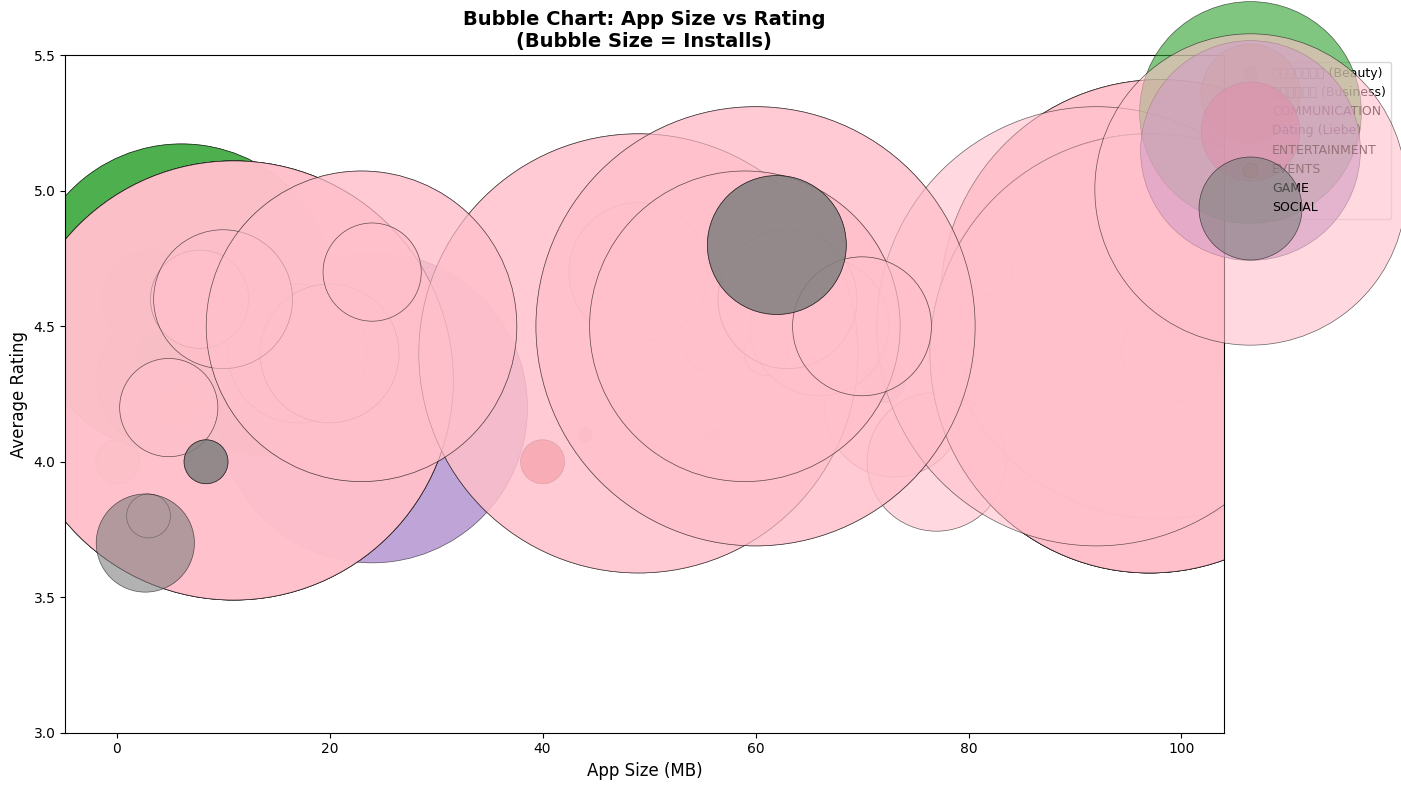

✅ Chart saved as task5_bubble_chart.png


In [4]:
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

# Check current IST time
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

print(f"Current IST hour: {current_hour}")

if not (17 <= current_hour < 19):
    print("⛔ Chart is only available between 5 PM and 7 PM IST. Please come back then.")

else:
    fig, ax = plt.subplots(figsize=(14, 8))

    categories = df['Category'].unique()
    colors = plt.cm.tab10.colors

    for i, cat in enumerate(categories):
        cat_data = df[df['Category'] == cat]

        # Pink color for GAME category
        color = 'pink' if cat == 'GAME' else colors[i % len(colors)]

        ax.scatter(
            cat_data['Size_MB'],
            cat_data['Rating'],
            s=cat_data['Installs'] / 1000,  # bubble size
            alpha=0.6,
            color=color,
            label=cat,
            edgecolors='black',
            linewidths=0.5
        )

    ax.set_xlabel('App Size (MB)', fontsize=12)
    ax.set_ylabel('Average Rating', fontsize=12)
    ax.set_title('Bubble Chart: App Size vs Rating\n(Bubble Size = Installs)',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=9)
    ax.set_ylim(3, 5.5)

    plt.tight_layout()
    plt.savefig('task5_bubble_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart saved as task5_bubble_chart.png")